In [ ]:
from google.colab import drive

drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/Research_Paper/b._Dataset/WESAD_Dataset/WESAD'

import os
print("Folders found in dataset:", os.listdir(dataset_path))

processed_path = '/content/drive/MyDrive/Research_Paper/WESAD_Processed_Data'

if not os.path.exists(processed_path):
    os.makedirs(processed_path)
    print(f"Created new folder: {processed_path}")
else:
    print("Folder already exists and is ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folders found in dataset: ['wesad_readme.pdf', 'S9', 'S6', 'S8', 'S5', 'S4', 'S7', 'S3', 'S16', 'S2', 'S17', 'S13', 'S14', 'S15', 'S11', 'S10']
Created new folder: /content/drive/MyDrive/Research_Paper/WESAD_Processed_Data


Unpickling and preprocessing of subject 2


===== Processing S2 =====
Data Loaded Successfully!
ECG shape: (4255300,)
EDA shape: (4255300,)
Labels shape: (4255300,)

Checking NaNs...
NaNs ECG: 0
NaNs EDA: 0
NaNs removed.

Starting chunk-wise cleaning...

Processed samples 0 to 42000
Processed samples 42000 to 84000
Processed samples 84000 to 126000
Processed samples 126000 to 168000
Processed samples 168000 to 210000
Processed samples 210000 to 252000
Processed samples 252000 to 294000
Processed samples 294000 to 336000
Processed samples 336000 to 378000
Processed samples 378000 to 420000
Processed samples 420000 to 462000
Processed samples 462000 to 504000
Processed samples 504000 to 546000
Processed samples 546000 to 588000
Processed samples 588000 to 630000
Processed samples 630000 to 672000
Processed samples 672000 to 714000
Processed samples 714000 to 756000
Processed samples 756000 to 798000
Processed samples 798000 to 840000
Processed samples 840000 to 882000
Processed samples 882000 to 924000
Processed samples 924000 to

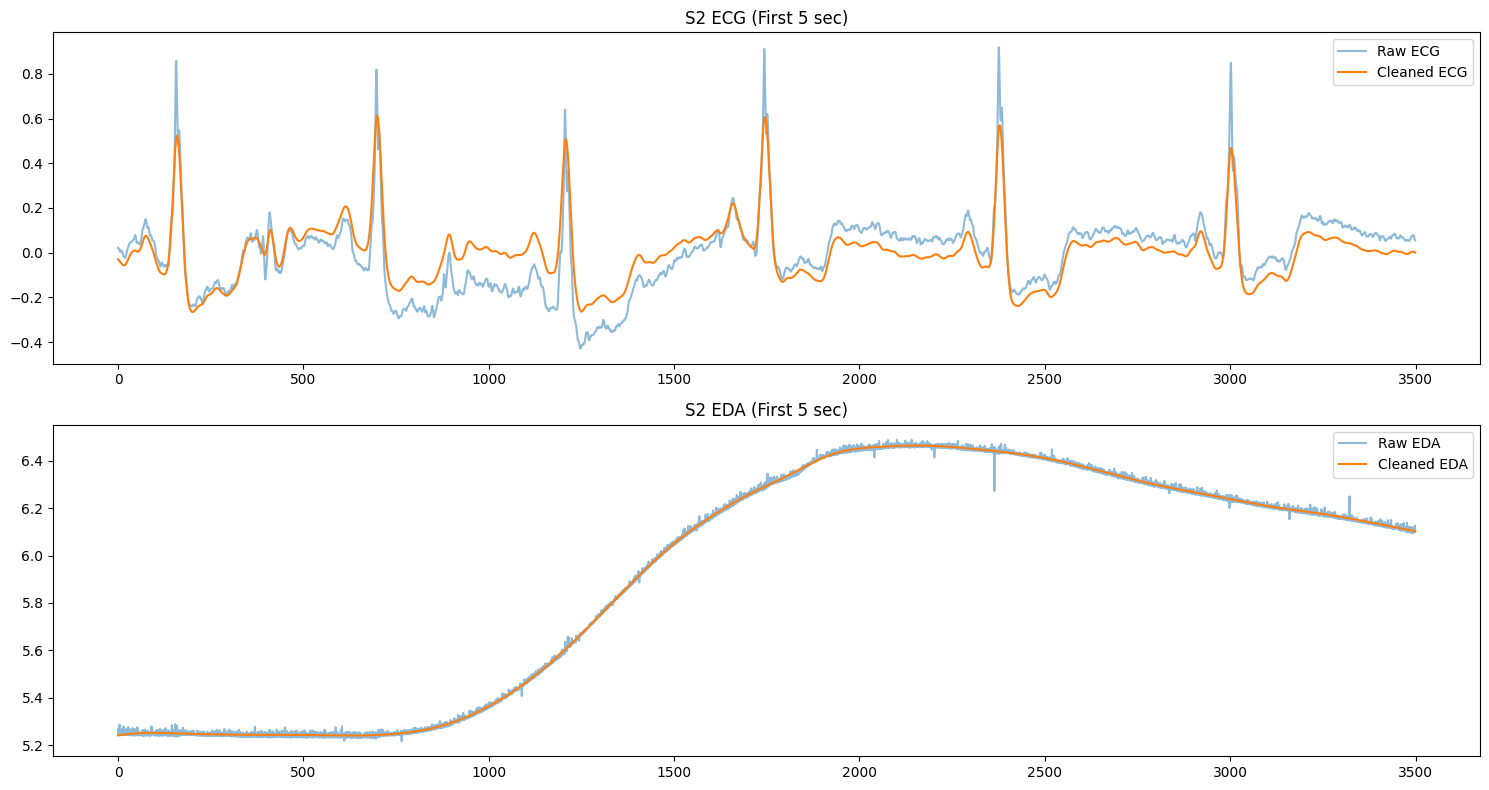


Pipeline Finished Successfully
Folder already exists and is ready.
Saving cleaned data to: /content/drive/MyDrive/Research_Paper/d. Results/WESAD_Processed_Data/S2_cleaned.csv
Processed S2 csv is saved


In [ ]:
import os
import pickle
import numpy as np
import neurokit2 as nk
import matplotlib.pyplot as plt
import gc

subject = "S2"
sampling_rate = 700
chunk_duration_sec = 60
dataset_path = "/content/drive/MyDrive/Research_Paper/b._Dataset/WESAD_Dataset/WESAD"

file_path = os.path.join(dataset_path, subject, f"{subject}.pkl")

print(f"\n===== Processing {subject} =====")

try:
    with open(file_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    chest = data["signal"]["chest"]
    ecg_raw = chest["ECG"].flatten()
    eda_raw = chest["EDA"].flatten()
    labels = data["label"]

    print("Data Loaded Successfully!")
    print("ECG shape:", ecg_raw.shape)
    print("EDA shape:", eda_raw.shape)
    print("Labels shape:", labels.shape)

    del data
    gc.collect()

except Exception as e:
    print(f"Error loading subject {subject}: {e}")
    raise


print("\nChecking NaNs...")
print("NaNs ECG:", np.isnan(ecg_raw).sum())
print("NaNs EDA:", np.isnan(eda_raw).sum())

ecg_raw = np.nan_to_num(ecg_raw)
eda_raw = np.nan_to_num(eda_raw)

print("NaNs removed.\n")

chunk_size = sampling_rate * chunk_duration_sec
total_samples = len(ecg_raw)

ecg_cleaned_full = []
eda_cleaned_full = []

print("Starting chunk-wise cleaning...\n")

for start in range(0, total_samples, chunk_size):

    end = min(start + chunk_size, total_samples)

    ecg_chunk = ecg_raw[start:end]
    eda_chunk = eda_raw[start:end]

    try:
        ecg_clean = nk.ecg_clean(ecg_chunk, sampling_rate=sampling_rate)
        eda_clean = nk.eda_clean(eda_chunk, sampling_rate=sampling_rate)

        ecg_cleaned_full.append(ecg_clean)
        eda_cleaned_full.append(eda_clean)

        print(f"Processed samples {start} to {end}")

    except Exception as e:
        print(f"Error in chunk {start}-{end}: {e}")
        break

    gc.collect()

ecg_cleaned_full = np.concatenate(ecg_cleaned_full)
eda_cleaned_full = np.concatenate(eda_cleaned_full)

print("\nCleaning Completed Successfully!")
print("Final ECG shape:", ecg_cleaned_full.shape)
print("Final EDA shape:", eda_cleaned_full.shape)

samples_to_plot = 5 * sampling_rate

plt.figure(figsize=(15, 8))

plt.subplot(2,1,1)
plt.plot(ecg_raw[:samples_to_plot], alpha=0.5, label="Raw ECG")
plt.plot(ecg_cleaned_full[:samples_to_plot], label="Cleaned ECG")
plt.title(f"{subject} ECG (First 5 sec)")
plt.legend()

plt.subplot(2,1,2)
plt.plot(eda_raw[:samples_to_plot], alpha=0.5, label="Raw EDA")
plt.plot(eda_cleaned_full[:samples_to_plot], label="Cleaned EDA")
plt.title(f"{subject} EDA (First 5 sec)")
plt.legend()

plt.tight_layout()
plt.show()

print("\nPipeline Finished Successfully")


import pandas as pd

processed_data = {
    'ECG_Clean': ecg_cleaned_full,
    'EDA_Clean': eda_cleaned_full,
    'Label': labels
}

df_processed = pd.DataFrame(processed_data)

processed_path = '/content/drive/MyDrive/Research_Paper/d. Results/WESAD_Processed_Data'

if not os.path.exists(processed_path):
    os.makedirs(processed_path)
    print(f"Created new folder: {processed_path}")
else:
    print("Folder already exists and is ready.")

save_path = os.path.join(processed_path, f"{subject}_cleaned.csv")

print(f"Saving cleaned data to: {save_path}")
df_processed.to_csv(save_path, index=False)

print("Processed S2 csv is saved")

other subjects apart from S2,S3 and S4

In [ ]:
import os
import pickle
import numpy as np
import neurokit2 as nk
import matplotlib.pyplot as plt
import gc
import pandas as pd

sampling_rate = 700
chunk_duration_sec = 60
dataset_path = "/content/drive/MyDrive/Research_Paper/b._Dataset/WESAD_Dataset/WESAD"
processed_path = '/content/drive/MyDrive/Research_Paper/d. Results/WESAD_Processed_Data'


subjects = ['S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']


for subject in subjects:
    file_path = os.path.join(dataset_path, subject, f"{subject}.pkl")
    save_path = os.path.join(processed_path, f"{subject}_cleaned.csv")

    if os.path.exists(save_path):
        print(f"Skipping {subject} - already processed.")
        continue

    print(f"\nProcessing {subject}...")

    try:
        with open(file_path, "rb") as f:
            data = pickle.load(f, encoding="latin1")

        chest = data["signal"]["chest"]
        ecg_raw = chest["ECG"].flatten()
        eda_raw = chest["EDA"].flatten()
        labels = data["label"]
        del data
        gc.collect()

        ecg_raw = np.nan_to_num(ecg_raw)
        eda_raw = np.nan_to_num(eda_raw)

        chunk_size = sampling_rate * chunk_duration_sec
        total_samples = len(ecg_raw)
        ecg_cleaned_full = []
        eda_cleaned_full = []

        for start in range(0, total_samples, chunk_size):
            end = min(start + chunk_size, total_samples)
            ecg_chunk = ecg_raw[start:end]
            eda_chunk = eda_raw[start:end]

            ecg_cleaned_full.append(nk.ecg_clean(ecg_chunk, sampling_rate=sampling_rate))
            eda_cleaned_full.append(nk.eda_clean(eda_chunk, sampling_rate=sampling_rate))

        ecg_cleaned_full = np.concatenate(ecg_cleaned_full)
        eda_cleaned_full = np.concatenate(eda_cleaned_full)


        samples_to_plot = 5 * sampling_rate
        plt.figure(figsize=(12, 6))

        plt.subplot(2,1,1)
        plt.plot(ecg_raw[:samples_to_plot], alpha=0.4, label="Raw", color='gray')
        plt.plot(ecg_cleaned_full[:samples_to_plot], label="Cleaned", color='red')
        plt.title(f"{subject} ECG Cleaning Check")
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(eda_raw[:samples_to_plot], alpha=0.4, label="Raw", color='gray')
        plt.plot(eda_cleaned_full[:samples_to_plot], label="Cleaned", color='blue')
        plt.title(f"{subject} EDA Cleaning Check")
        plt.legend()

        plt.tight_layout()
        plt.close()


        df_processed = pd.DataFrame({
            'ECG_Clean': ecg_cleaned_full,
            'EDA_Clean': eda_cleaned_full,
            'Label': labels
        })
        df_processed.to_csv(save_path, index=False)
        print(f"{subject} CSV saved.")


        del ecg_raw, eda_raw, ecg_cleaned_full, eda_cleaned_full, df_processed, labels
        gc.collect()

    except Exception as e:
        print(f"Error processing {subject}: {e}")

print("\n BATCH COMPLETE!")


Processing S5...
S5 CSV saved.

Processing S6...
S6 CSV saved.

Processing S7...
S7 CSV saved.

Processing S8...
S8 CSV saved.

Processing S9...
S9 CSV saved.

Processing S10...
S10 CSV saved.

Processing S11...
S11 CSV saved.

Processing S13...
S13 CSV saved.

Processing S14...
S14 CSV saved.

Processing S15...
S15 CSV saved.

Processing S16...
S16 CSV saved.

Processing S17...
S17 CSV saved.

 BATCH COMPLETE!


verification plots

Generating comparison for S5...


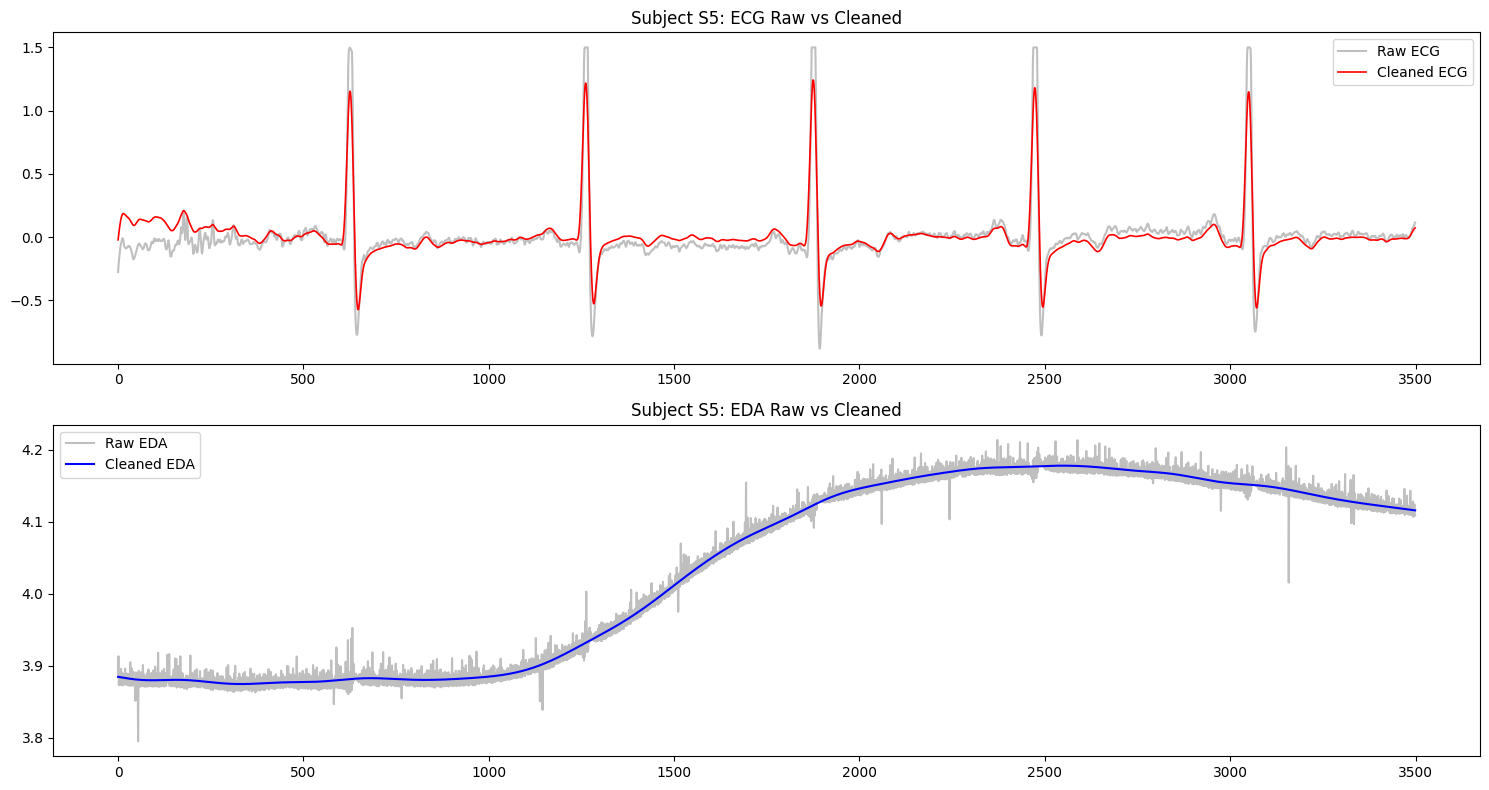

Generating comparison for S6...


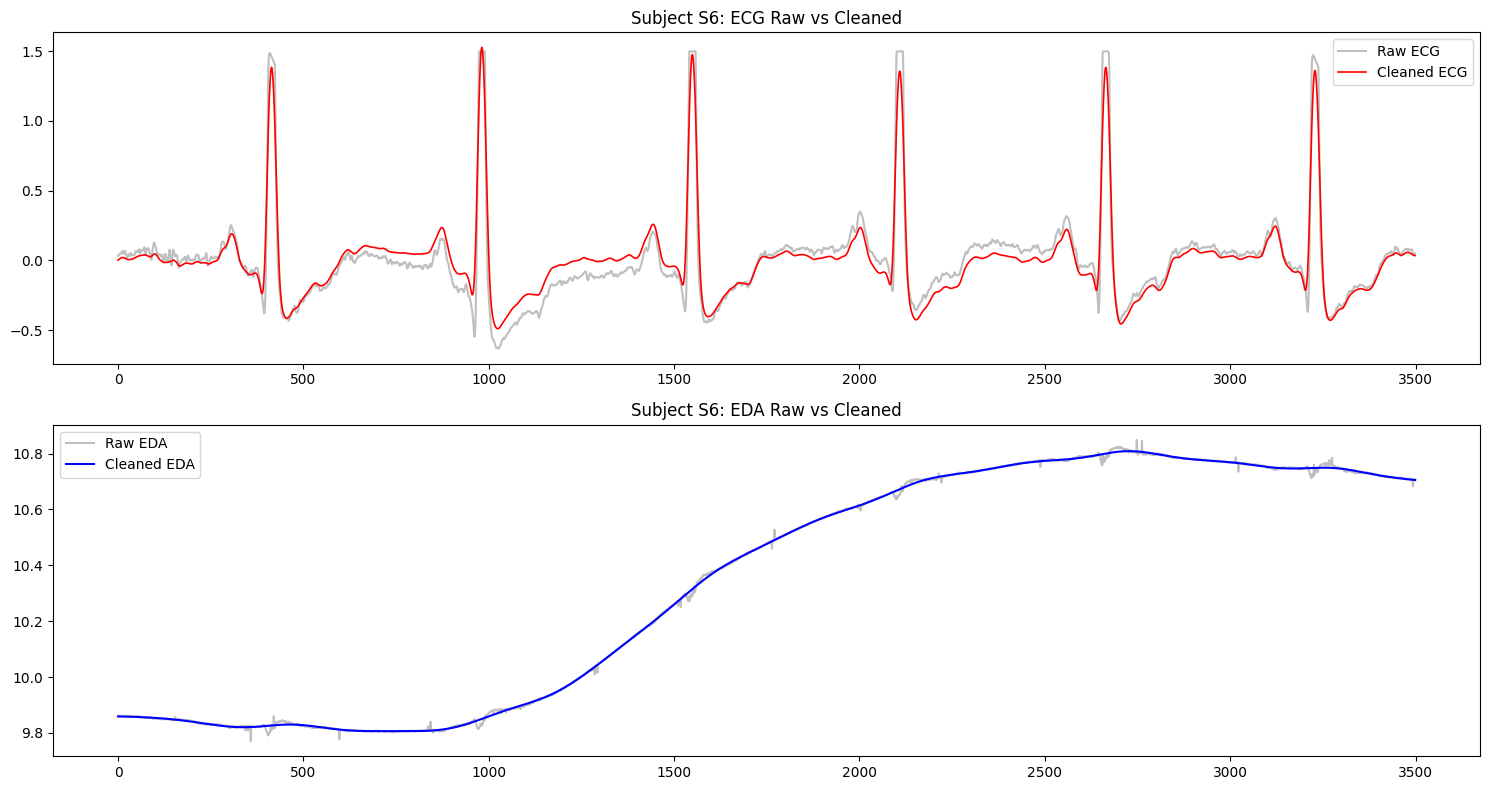

Generating comparison for S7...


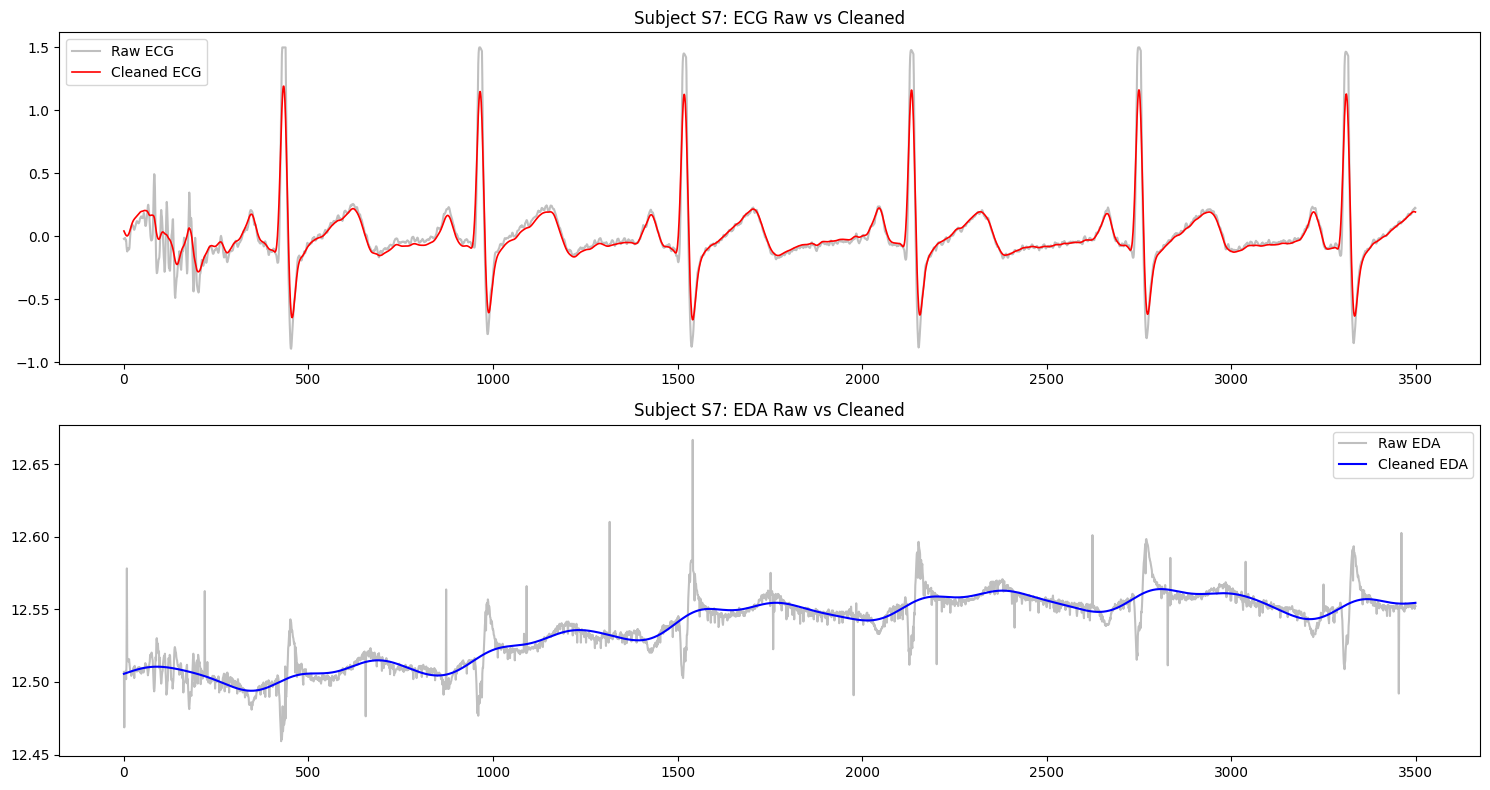

Generating comparison for S8...


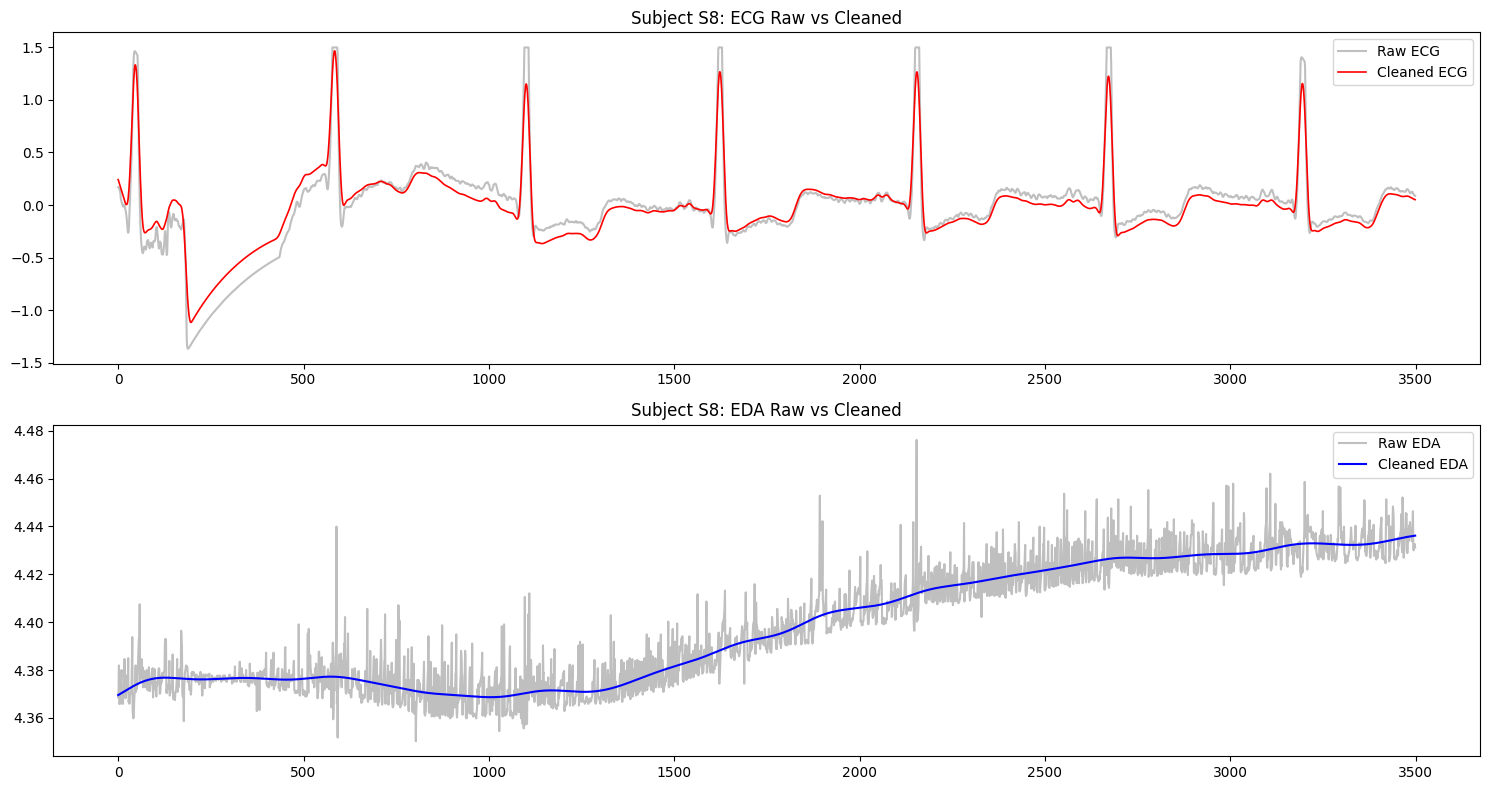

Generating comparison for S9...


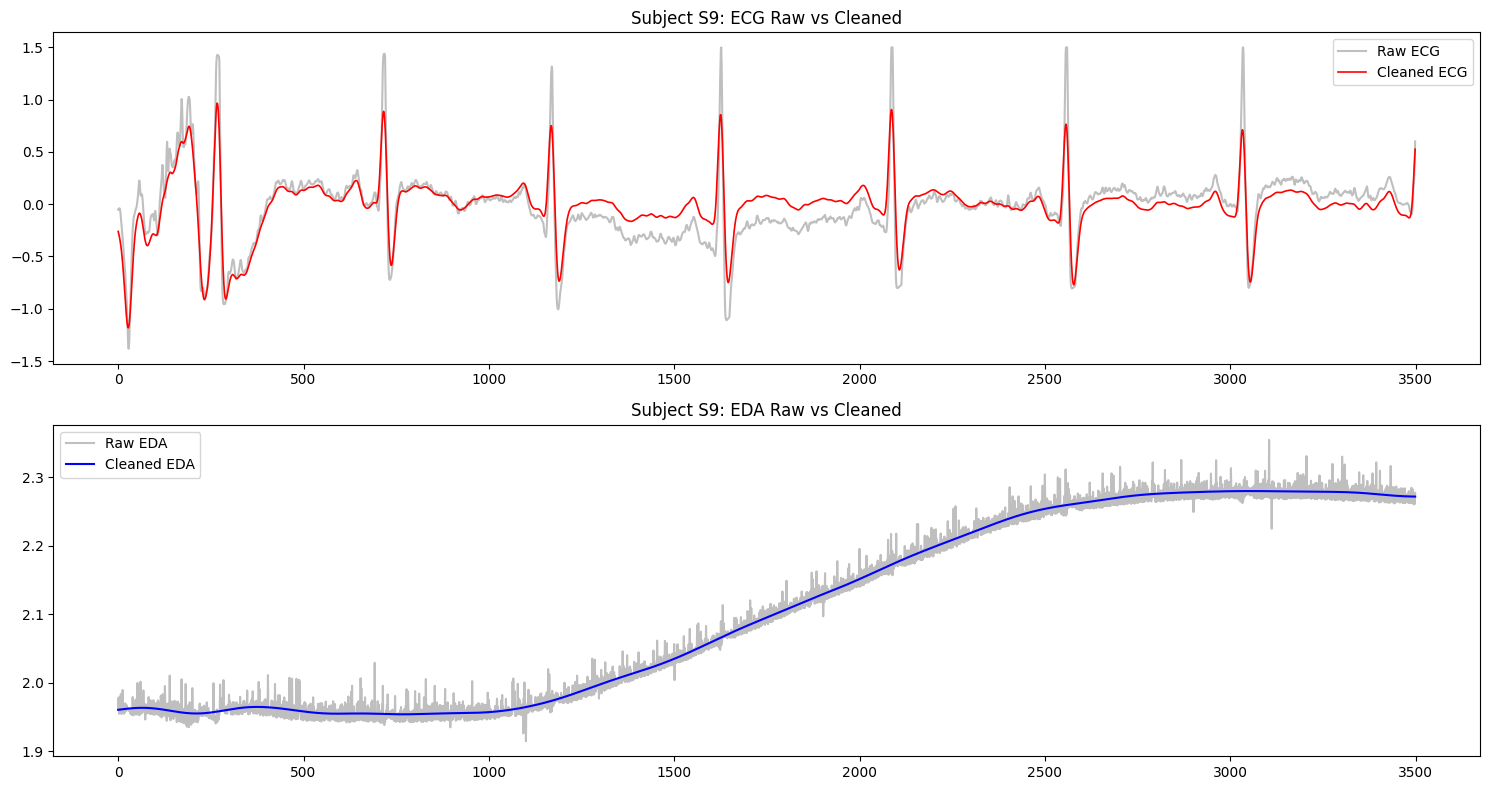

Generating comparison for S10...


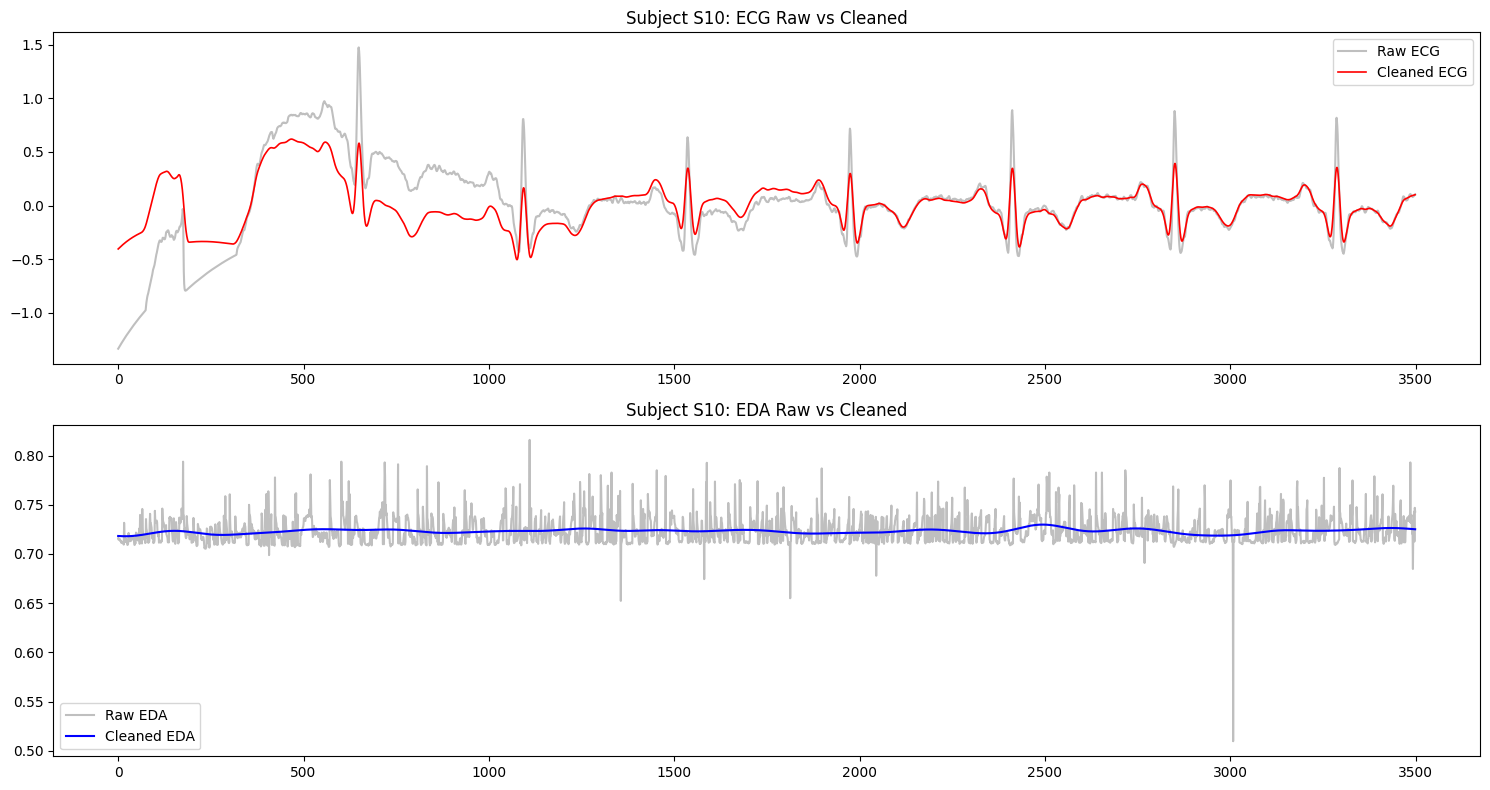

Generating comparison for S11...


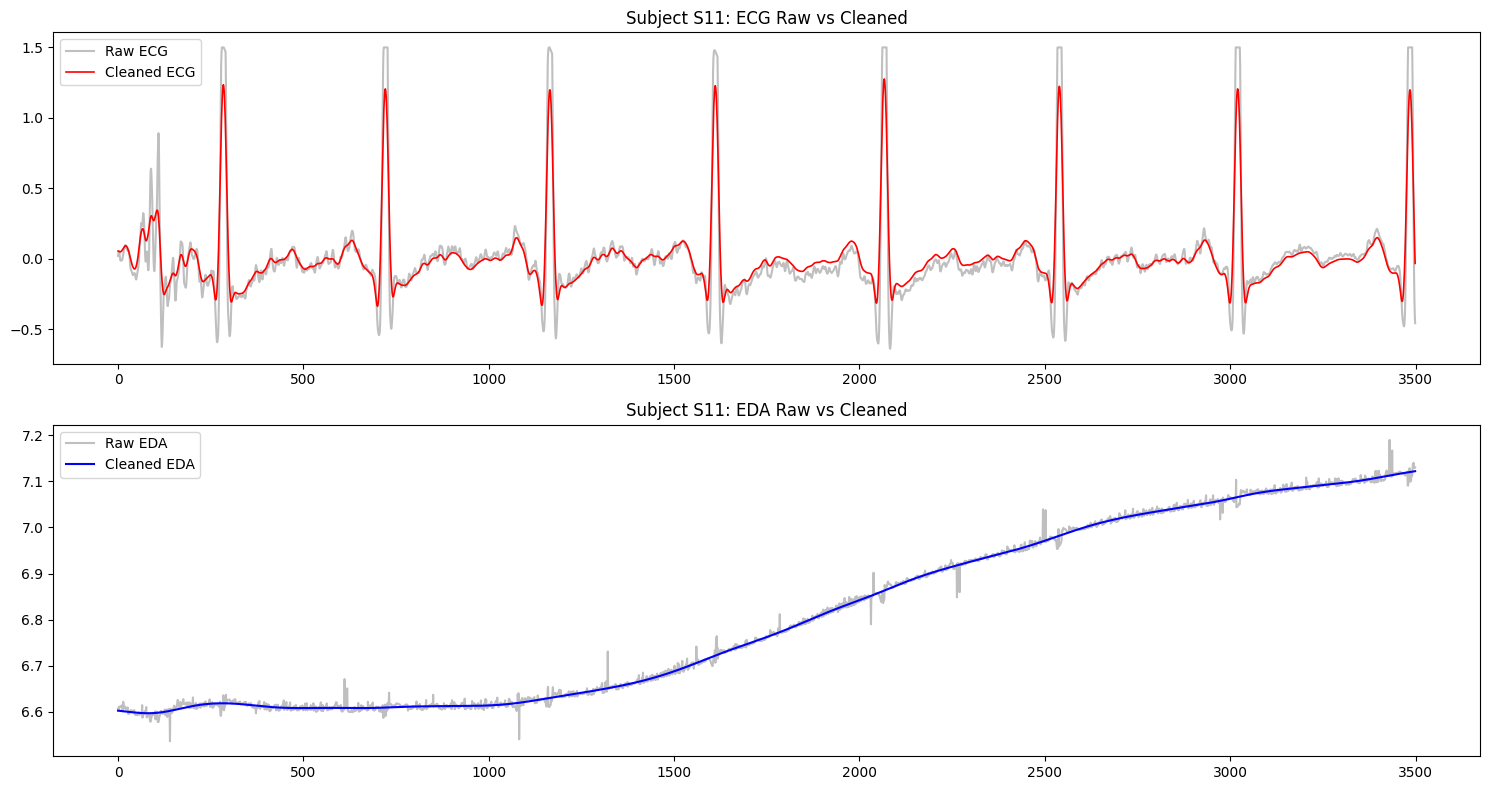

Generating comparison for S13...


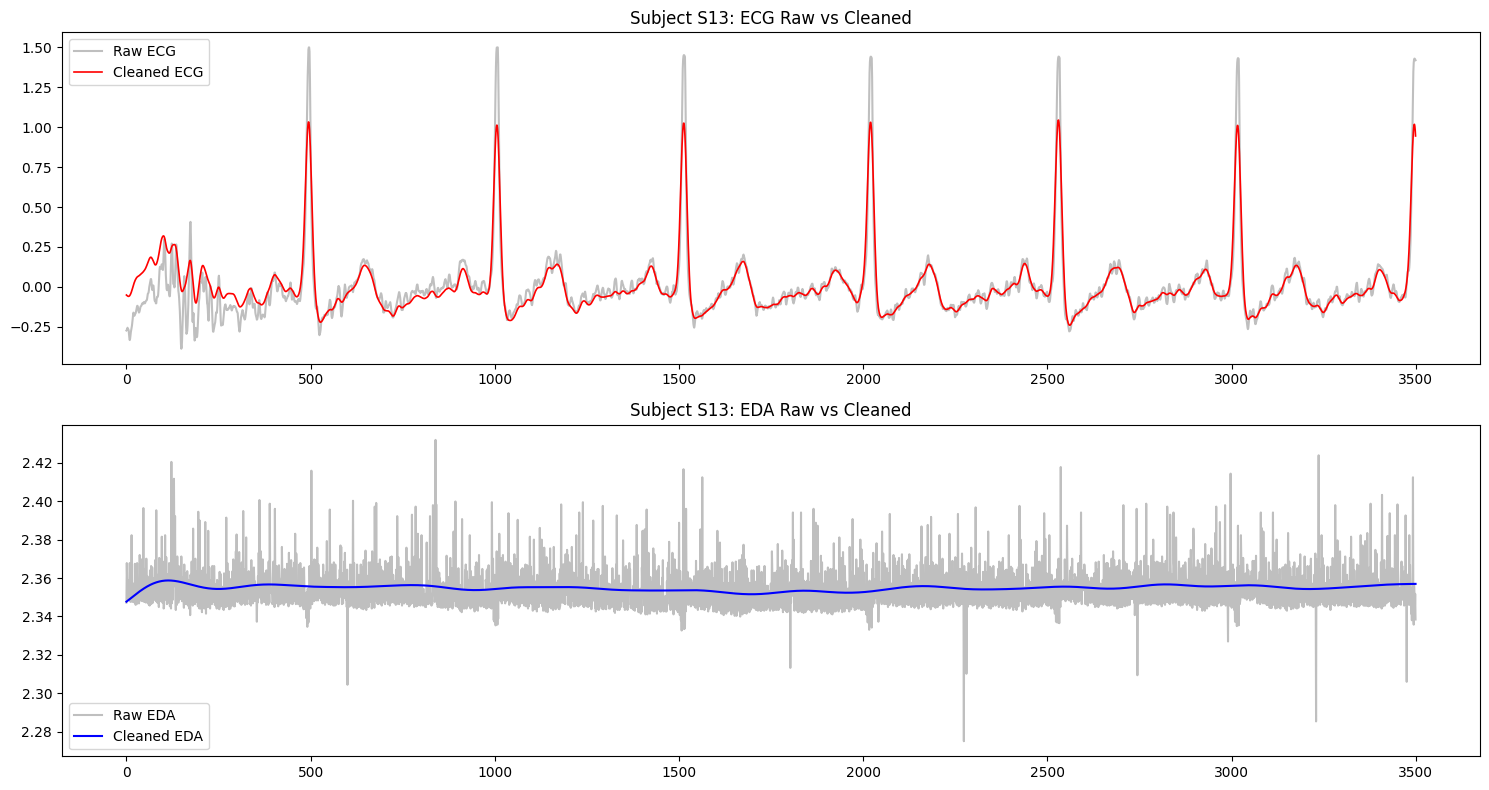

Generating comparison for S14...


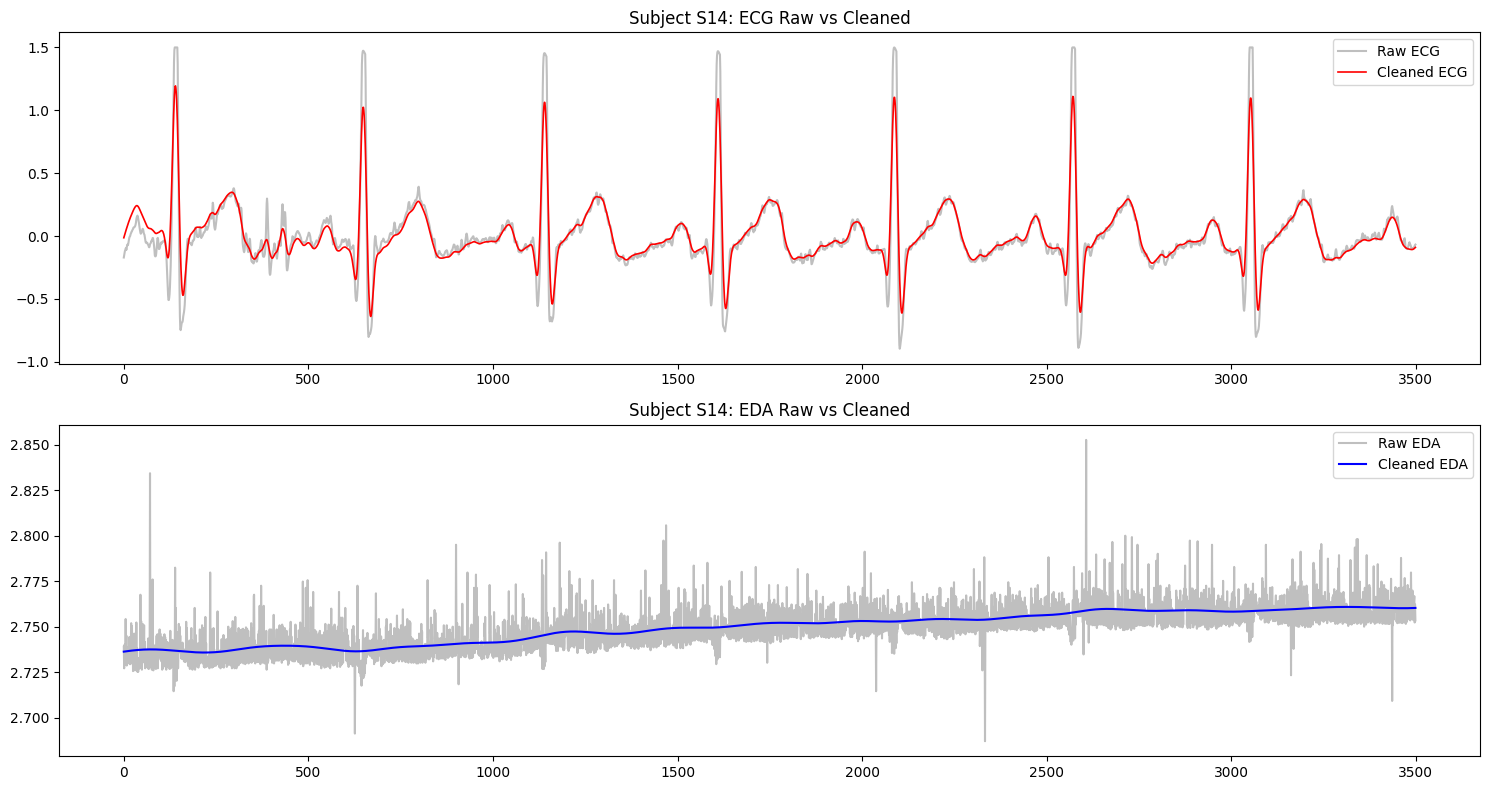

Generating comparison for S15...


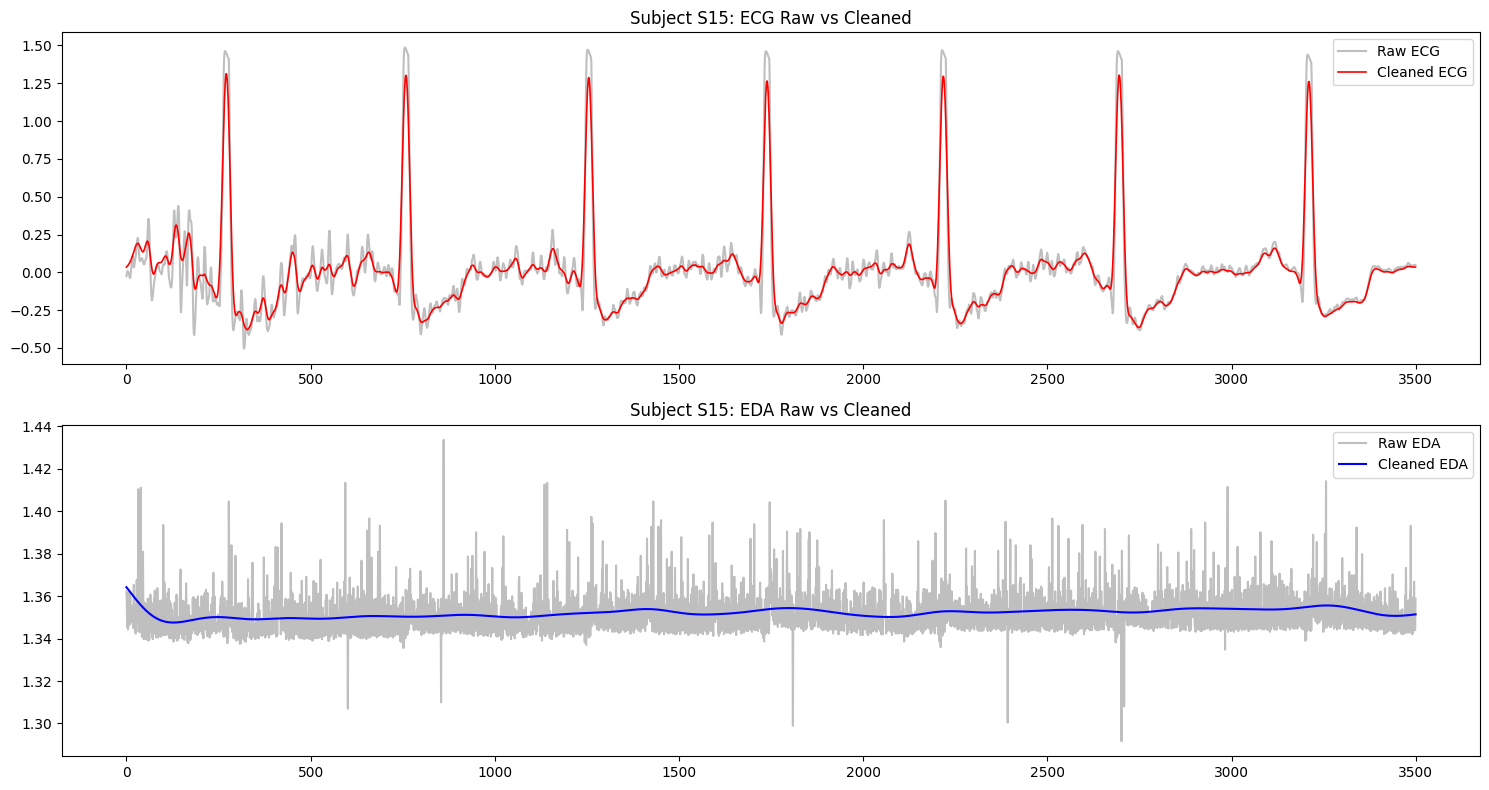

Generating comparison for S16...


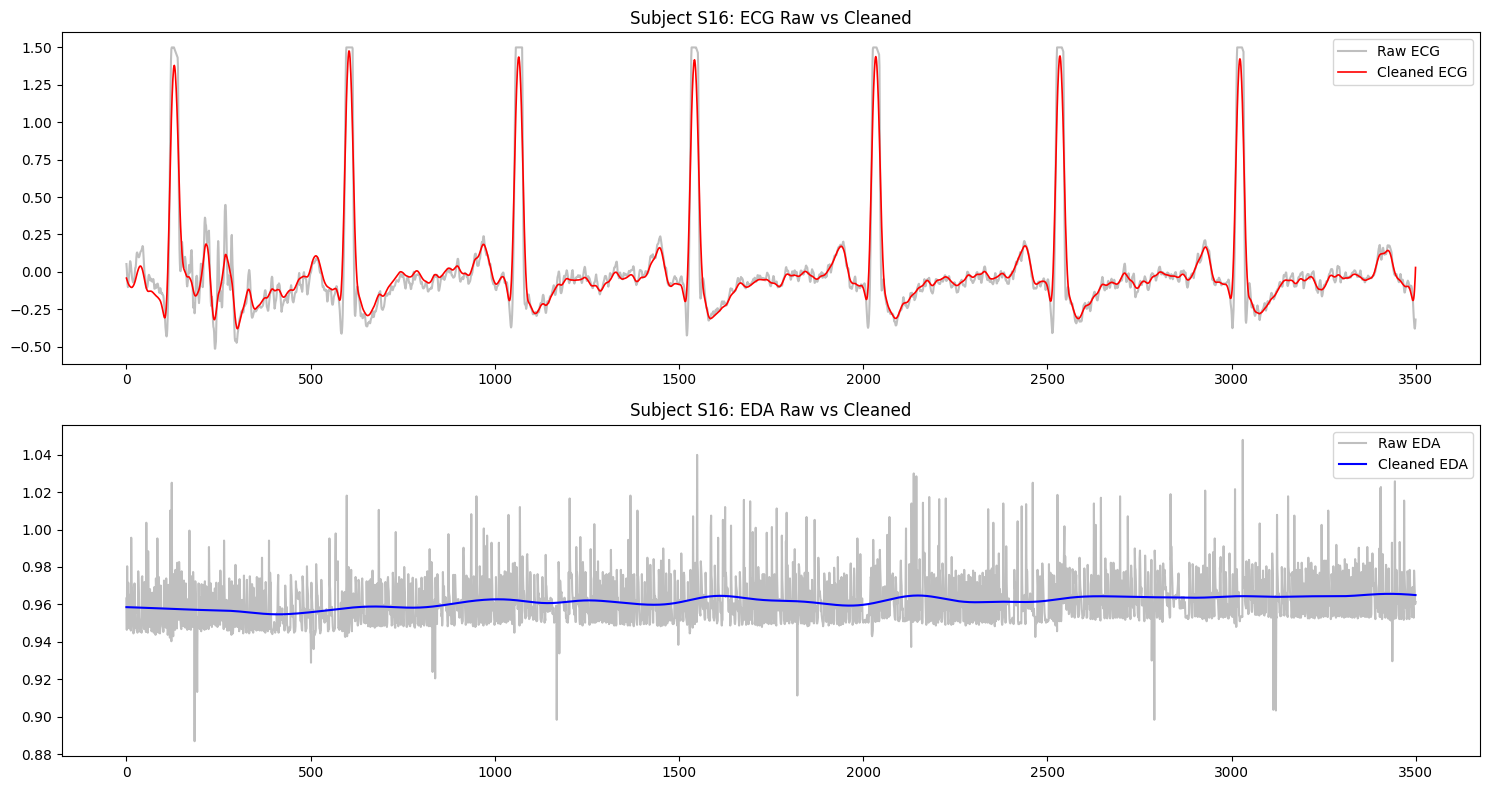

Generating comparison for S17...


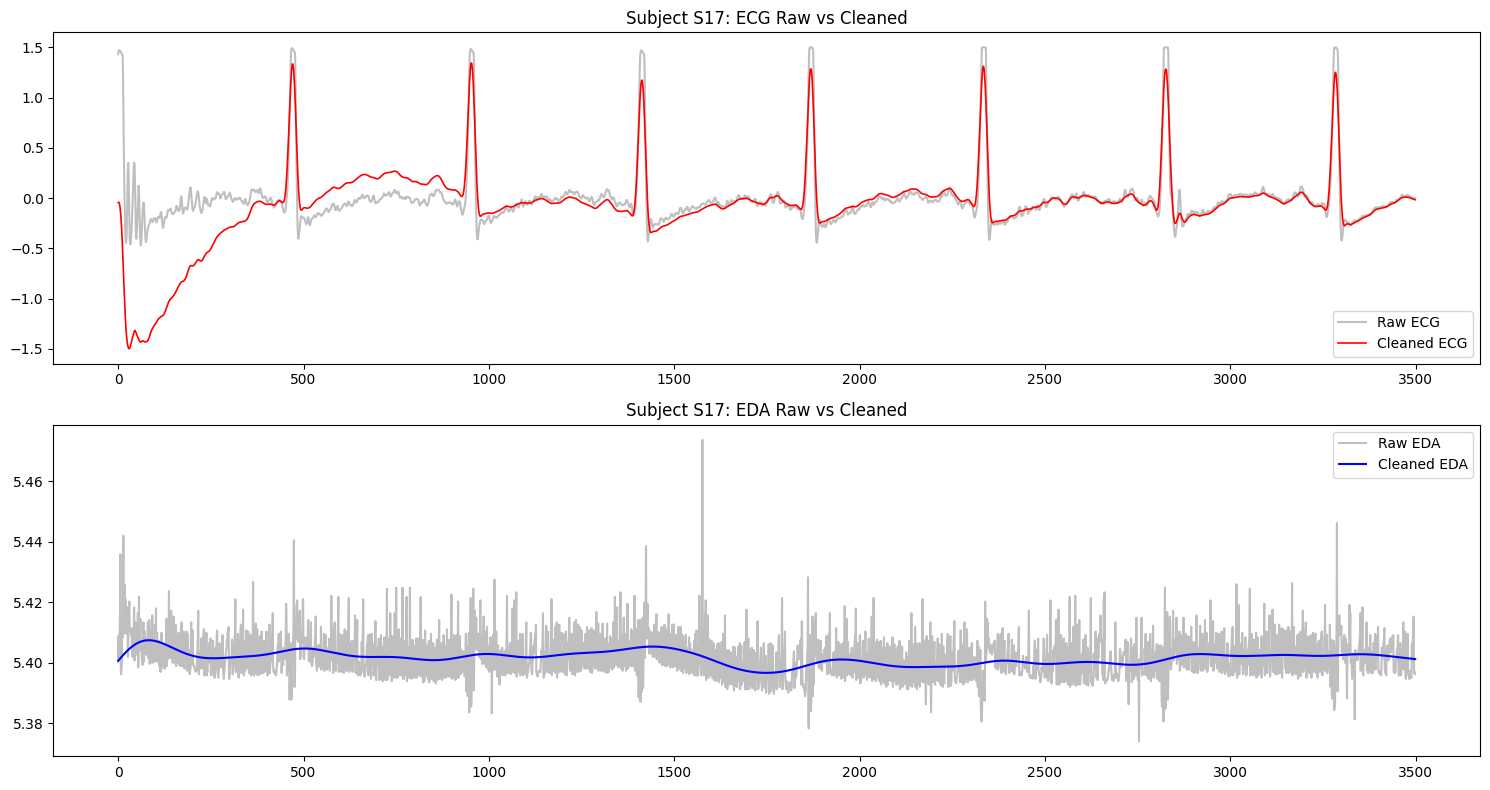

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle

dataset_path = "/content/drive/MyDrive/Research_Paper/b._Dataset/WESAD_Dataset/WESAD"
processed_path = '/content/drive/MyDrive/Research_Paper/d. Results/WESAD_Processed_Data'

subjects = ['S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
samples = 5 * 700

for sub in subjects:
    print(f"Generating comparison for {sub}...")

    pkl_path = os.path.join(dataset_path, sub, f"{sub}.pkl")
    with open(pkl_path, "rb") as f:
        raw_data = pickle.load(f, encoding="latin1")
    ecg_raw = raw_data["signal"]["chest"]["ECG"].flatten()[:samples]
    eda_raw = raw_data["signal"]["chest"]["EDA"].flatten()[:samples]
    del raw_data


    csv_path = os.path.join(processed_path, f"{sub}_cleaned.csv")
    df_clean = pd.read_csv(csv_path, nrows=samples)

    plt.figure(figsize=(15, 8))

    plt.subplot(2, 1, 1)
    plt.plot(ecg_raw, color='gray', alpha=0.5, label='Raw ECG')
    plt.plot(df_clean['ECG_Clean'], color='red', label='Cleaned ECG', linewidth=1.2)
    plt.title(f"Subject {sub}: ECG Raw vs Cleaned")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(eda_raw, color='gray', alpha=0.5, label='Raw EDA')
    plt.plot(df_clean['EDA_Clean'], color='blue', label='Cleaned EDA', linewidth=1.5)
    plt.title(f"Subject {sub}: EDA Raw vs Cleaned")
    plt.legend()

    plt.tight_layout()
    plt.show()